1. Logistic Regression Model

Logistic Regression Detailed Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.95      0.92       681
     Dropout       0.80      0.67      0.73       216

    accuracy                           0.88       897
   macro avg       0.85      0.81      0.83       897
weighted avg       0.88      0.88      0.88       897

Test Set Accuracy: 0.8796 (87.96%)
Best Hyperparameter (C): 10
Best Cross-Validation Accuracy: 0.8714


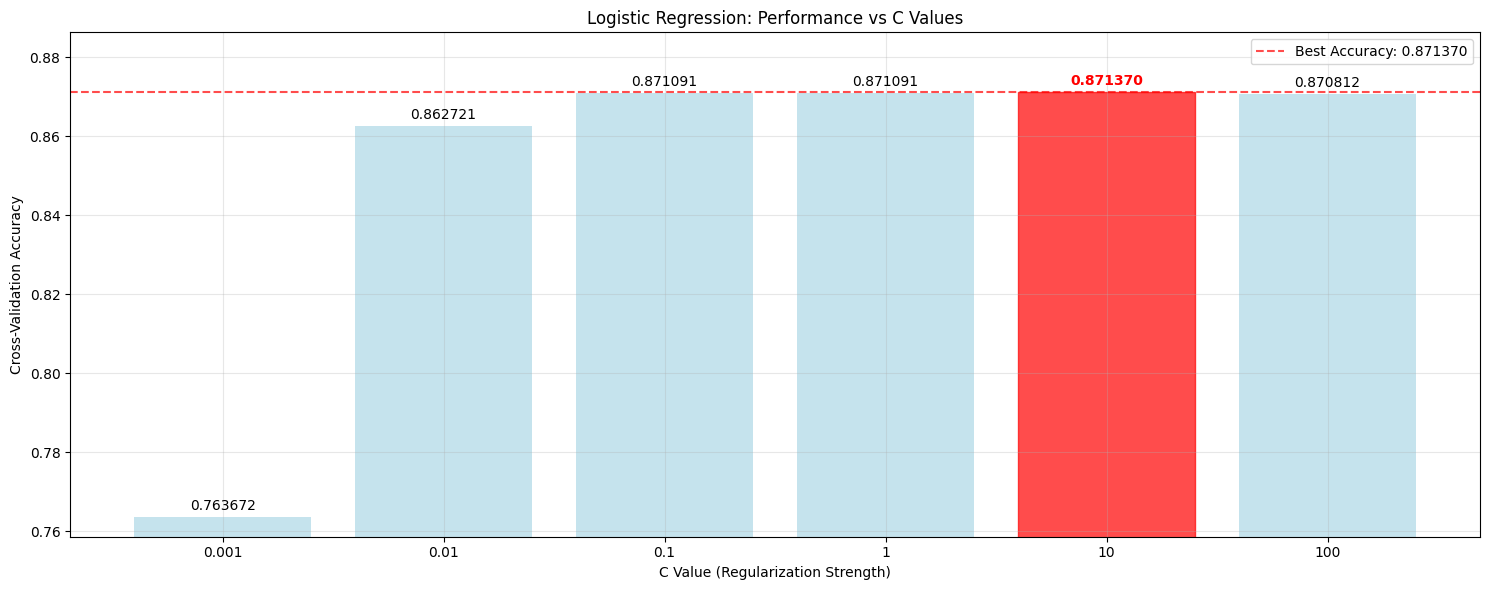


2. Support Vector Classifier (SVC)

SVC Detailed Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.96      0.93       681
     Dropout       0.84      0.66      0.74       216

    accuracy                           0.89       897
   macro avg       0.87      0.81      0.83       897
weighted avg       0.88      0.89      0.88       897

Test Set Accuracy: 0.8874 (88.74%)
Best Hyperparameter (Kernel): rbf
Best Cross-Validation Accuracy: 0.8764


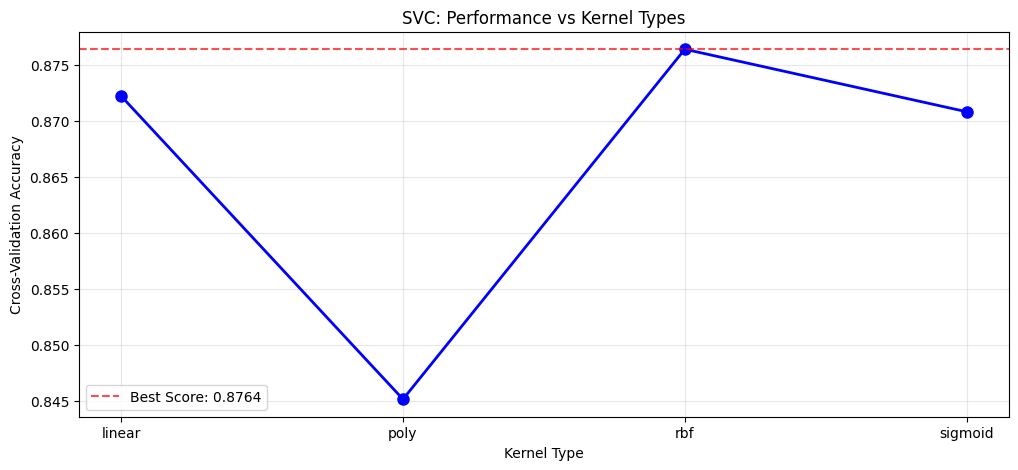


3. K-Nearest Neighbors (KNN)

KNN Detailed Report:
              precision    recall  f1-score   support

 Non-Dropout       0.79      0.97      0.87       681
     Dropout       0.68      0.19      0.30       216

    accuracy                           0.78       897
   macro avg       0.74      0.58      0.58       897
weighted avg       0.77      0.78      0.73       897

Test Set Accuracy: 0.7837 (78.37%)
Best Hyperparameter (k): 7
Best Cross-Validation Accuracy: 0.7840


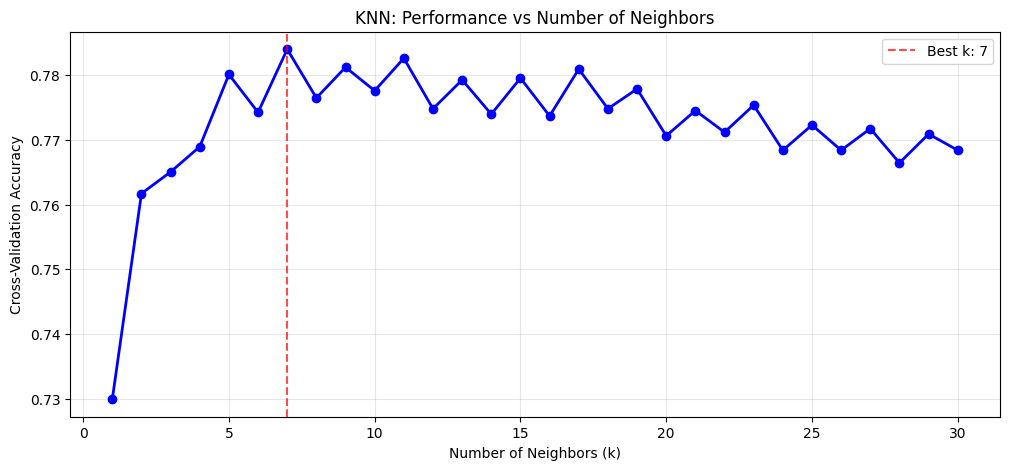


4. Random Forest

Random Forest Detailed Report:
              precision    recall  f1-score   support

 Non-Dropout       1.00      1.00      1.00       681
     Dropout       1.00      1.00      1.00       216

    accuracy                           1.00       897
   macro avg       1.00      1.00      1.00       897
weighted avg       1.00      1.00      1.00       897

Test Set Accuracy: 1.0000 (100.00%)
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.9947

Confusion Matrix (Test Set):
--------------------------------------------------
                    Prediction
              Non-Dropout (0)  Dropout (1)
Actual Non-Dropout (0)    681             0              
Actual Dropout (1)        0               216            
--------------------------------------------------

Key Metrics:
1. Recall (Dropout): 1.0000
2. Precision (Dropout): 1.0000
3. F1 Score (Dropou

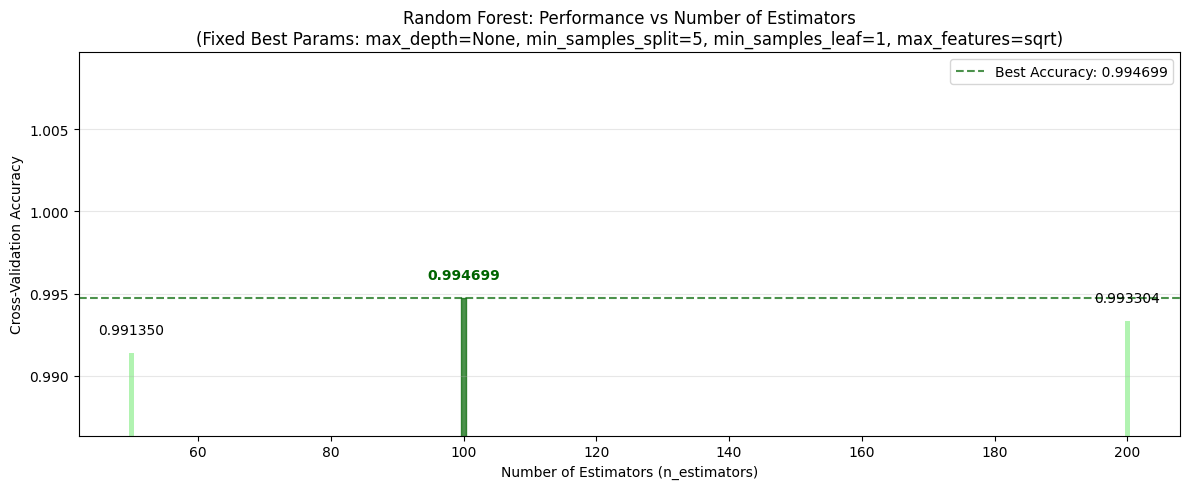


5. Naive Bayes (Gaussian)

Naive Bayes Detailed Report:
              precision    recall  f1-score   support

 Non-Dropout       0.87      0.98      0.92       681
     Dropout       0.90      0.54      0.67       216

    accuracy                           0.87       897
   macro avg       0.88      0.76      0.80       897
weighted avg       0.88      0.87      0.86       897

Test Set Accuracy: 0.8740 (87.40%)
Best Hyperparameters: {'var_smoothing': 1e-08}
Best Cross-Validation Accuracy: 0.8518

Confusion Matrix (Test Set):
--------------------------------------------------
                    Prediction
              Non-Dropout (0)  Dropout (1)
Actual Non-Dropout (0)    668             13             
Actual Dropout (1)        100             116            
Total                     768             129            
--------------------------------------------------

Key Metrics:
1. Recall (Dropout): 0.5370
2. Precision (Dropout): 0.8992
3. F1 Score (Dropout): 0.6725
4. Accuracy:

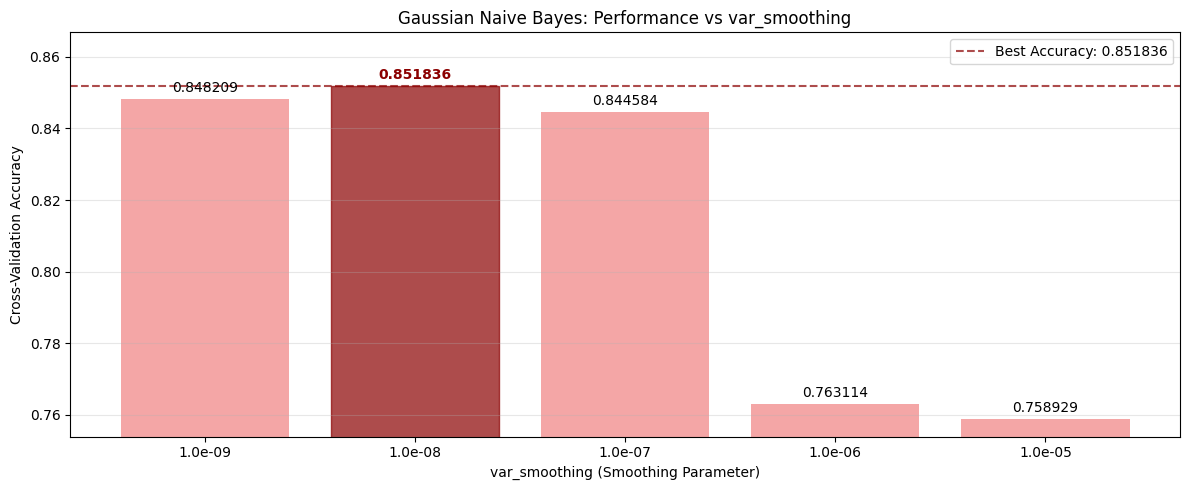


Learning Curves (Individual Models)


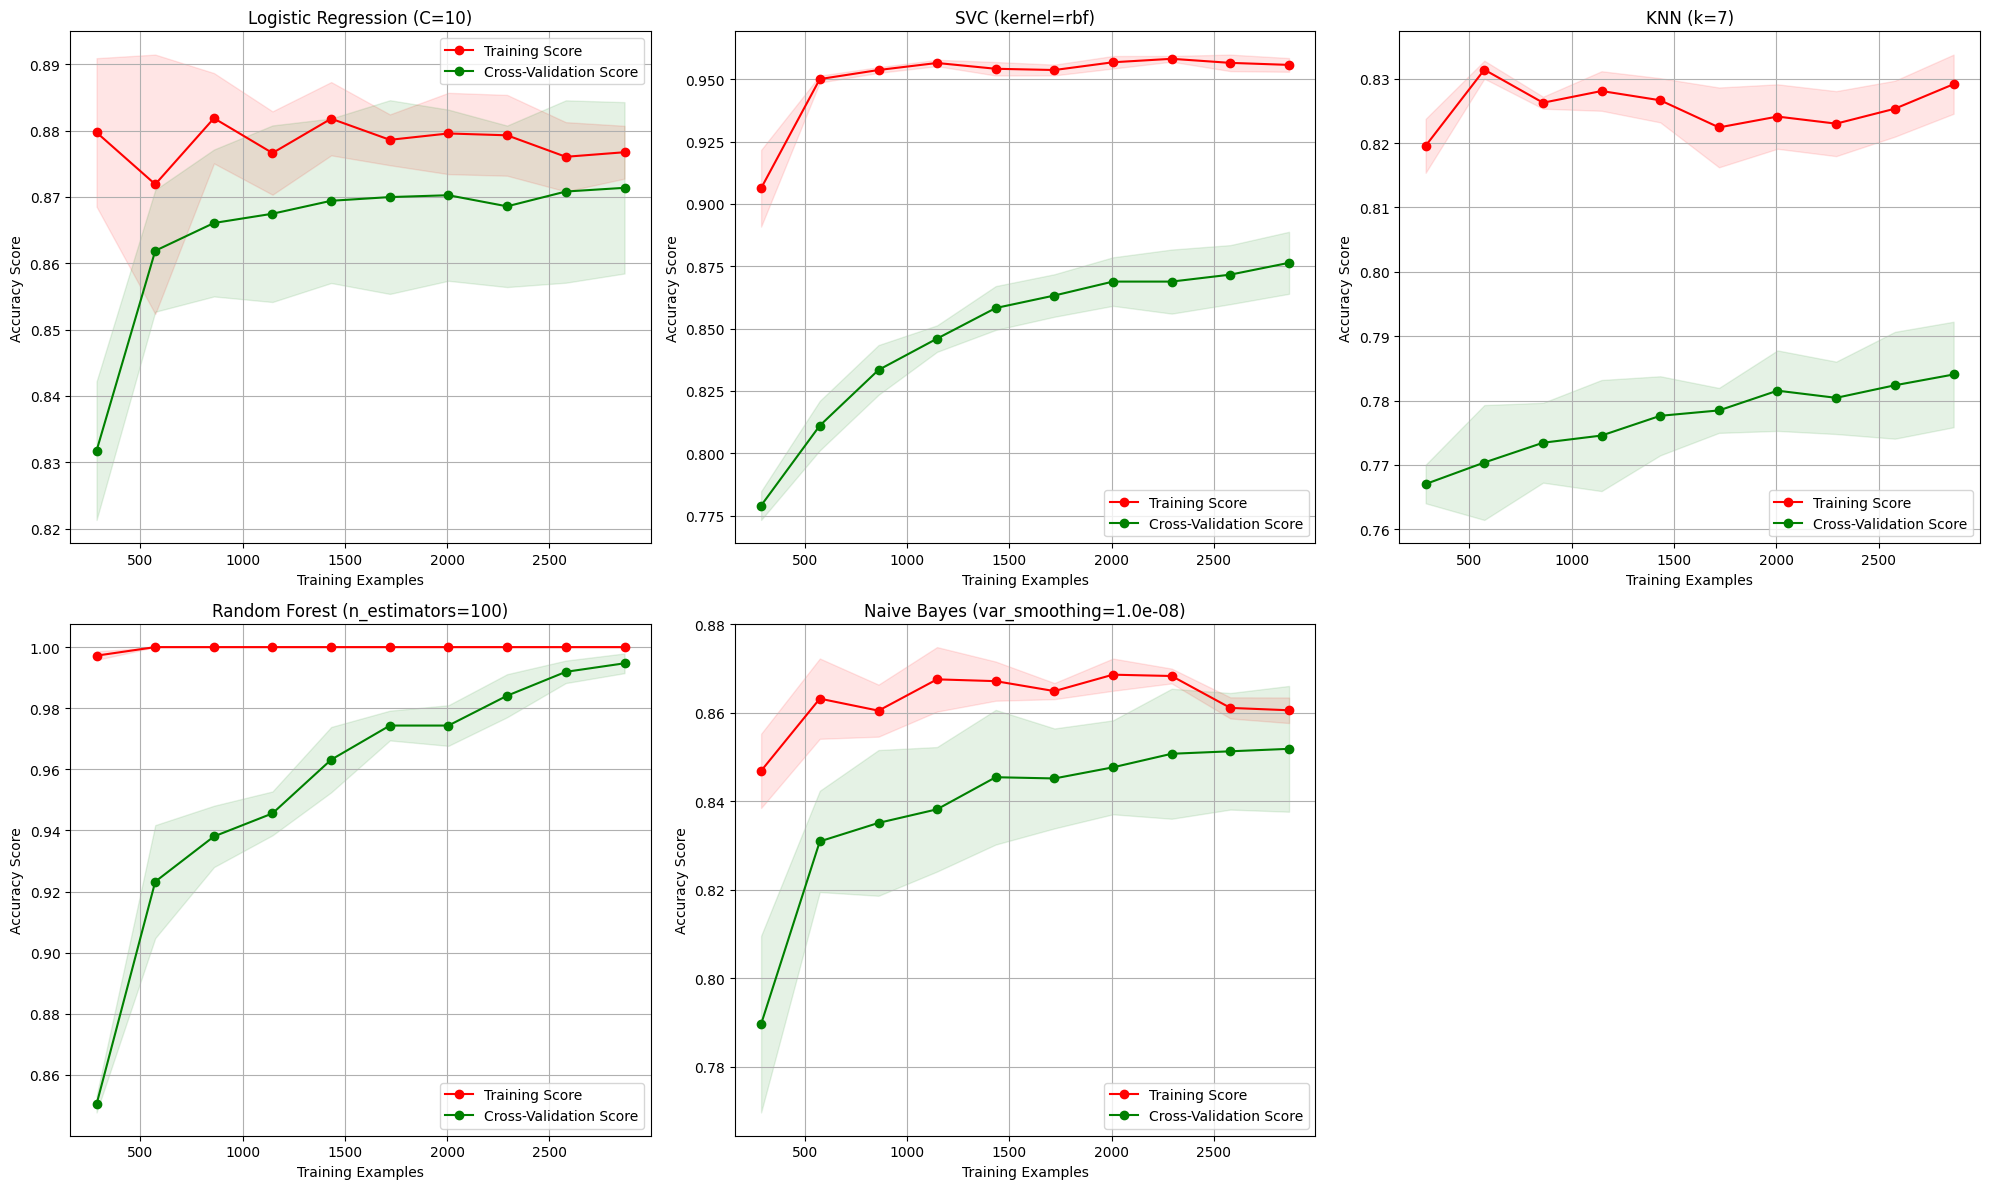


Learning Curves (Model Comparison)


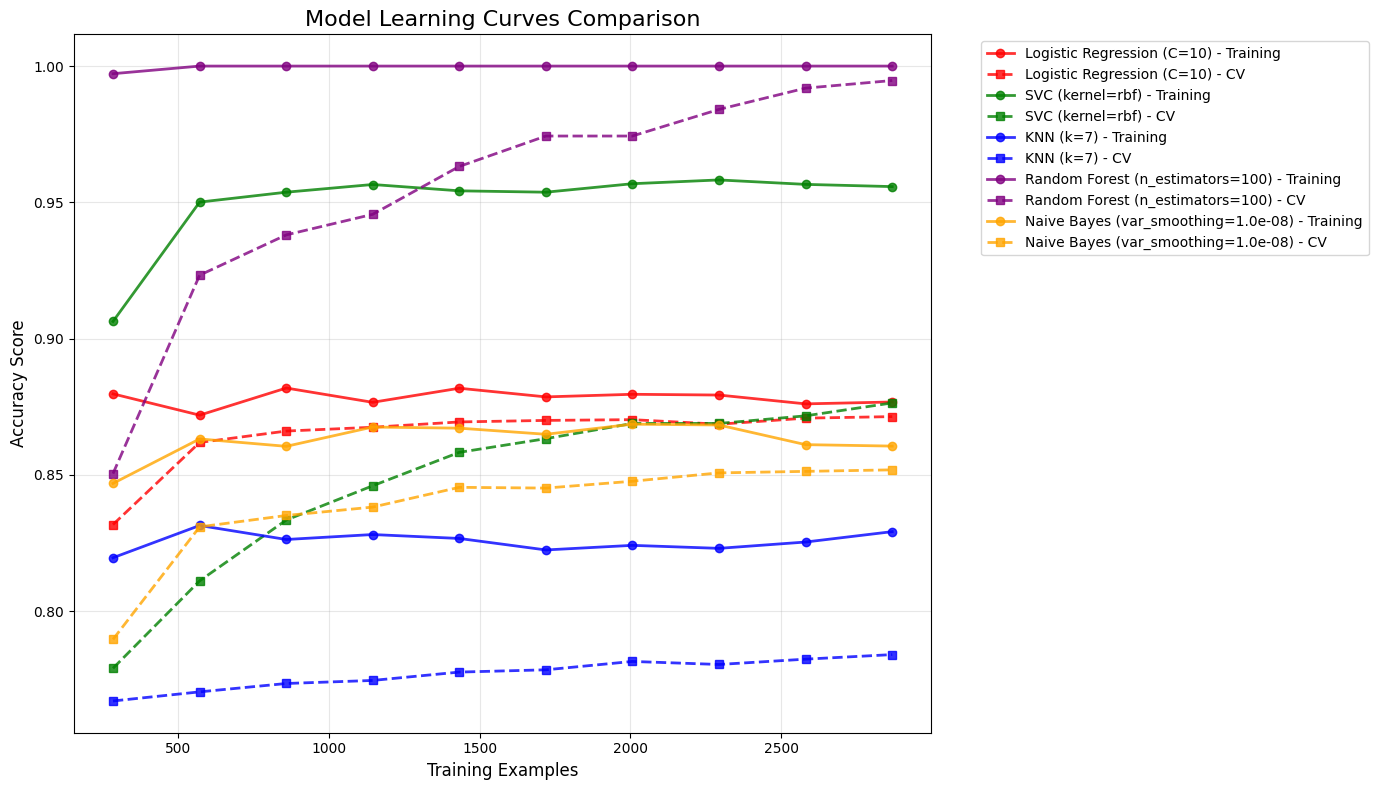


LEARNING CURVE ANALYSIS SUMMARY

Logistic Regression (C=10):
  Final Training Score: 0.8767
  Final Validation Score: 0.8714
  Training-Validation Gap: 0.0054
  → Good fit (small gap and high validation score)

SVC (kernel=rbf):
  Final Training Score: 0.9558
  Final Validation Score: 0.8764
  Training-Validation Gap: 0.0794
  → Normal fit

KNN (k=7):
  Final Training Score: 0.8292
  Final Validation Score: 0.7840
  Training-Validation Gap: 0.0451
  → Good fit (small gap and high validation score)

Random Forest (n_estimators=100):
  Final Training Score: 1.0000
  Final Validation Score: 0.9947
  Training-Validation Gap: 0.0053
  → Good fit (small gap and high validation score)

Naive Bayes (var_smoothing=1.0e-08):
  Final Training Score: 0.8606
  Final Validation Score: 0.8518
  Training-Validation Gap: 0.0087
  → Good fit (small gap and high validation score)


In [ ]:
# -*- coding: utf-8 -*-
"""Combined Model Analysis: Logistic Regression, SVC, KNN, Random Forest, and Naive Bayes"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Load dataset
data = pd.read_csv('https://raw.githubusercontent.com/Salina-Huang/AI-in-ED-Multi-dimensional-Student-analytics-for-dropout-risk-prediction/refs/heads/main/Preparation_data_onehot.csv')

# Split features and target variable
X = data.drop('dropout_status', axis=1)
y = data['dropout_status']

# Standardize features (required for Logistic Regression, SVC, KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
# For models requiring scaled features (Logistic Regression, SVC, KNN)
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# For models not requiring scaling (Random Forest, Naive Bayes)
X_train, X_test, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

target_names = ['Non-Dropout', 'Dropout']


# 1. Logistic Regression with GridSearchCV
print("="*70)
print("1. Logistic Regression Model")
print("="*70)

# Define hyperparameter grid
logistic_param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize and run GridSearchCV
logistic_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=logistic_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
logistic_grid_search.fit(X_train_scaled, y_train)

# Extract best model and results
best_logistic_model = logistic_grid_search.best_estimator_
best_C = logistic_grid_search.best_params_['C']
best_C_scores = logistic_grid_search.best_score_
logistic_scores_final = logistic_grid_search.cv_results_['mean_test_score']
C_range = [param['C'] for param in logistic_grid_search.cv_results_['params']]

# Evaluate on test set
best_logistic_predict = best_logistic_model.predict(X_test_scaled)
logistic_accuracy = accuracy_score(y_test, best_logistic_predict)

print('\nLogistic Regression Detailed Report:')
print(classification_report(y_test, best_logistic_predict, target_names=target_names))
print(f'Test Set Accuracy: {logistic_accuracy:.4f} ({logistic_accuracy*100:.2f}%)')
print(f'Best Hyperparameter (C): {best_C}')
print(f'Best Cross-Validation Accuracy: {best_C_scores:.4f}')

# Confusion Matrix for Logistic Regression
lr_cm = confusion_matrix(y_test, best_logistic_predict)
tn, fp, fn, tp = lr_cm.ravel()
print("\nLogistic Regression Confusion Matrix (Test Set):")
print("-"*50)
print(f"                    Prediction")
print(f"              Non-Dropout (0)  Dropout (1)")
print(f"Actual Non-Dropout (0)    {tn:<15} {fp:<15}")
print(f"Actual Dropout (1)        {fn:<15} {tp:<15}")
print("-"*50)

recall_dropout = tp / (tp + fn) if (tp + fn) != 0 else 0.0
precision_dropout = tp / (tp + fp) if (tp + fp) != 0 else 0.0
f1_dropout = 2 * (precision_dropout * recall_dropout) / (precision_dropout + recall_dropout) if (precision_dropout + recall_dropout) != 0 else 0.0
print("\nKey Metrics:")
print(f"1. Recall (Dropout): {recall_dropout:.4f}")
print(f"2. Precision (Dropout): {precision_dropout:.4f}")
print(f"3. F1 Score (Dropout): {f1_dropout:.4f}")
print(f"4. Accuracy: {logistic_accuracy:.4f}")

# Plot performance vs C values
plt.figure(figsize=(15, 6))
bars = plt.bar(range(len(C_range)), logistic_scores_final, color='lightblue', alpha=0.7)
best_index = np.argmax(logistic_scores_final)
bars[best_index].set_color('red')

for i, (c, score) in enumerate(zip(C_range, logistic_scores_final)):
    plt.text(i, score + 0.001, f'{score:.6f}',
             ha='center', va='bottom', fontsize=10,
             fontweight='bold' if i == best_index else 'normal',
             color='red' if i == best_index else 'black')

plt.axhline(y=best_C_scores, color='red', linestyle='--', alpha=0.7,
           label=f'Best Accuracy: {best_C_scores:.6f}')
plt.xlabel('C Value (Regularization Strength)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Logistic Regression: Performance vs C Values')
plt.xticks(range(len(C_range)), C_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(min(logistic_scores_final) - 0.005, max(logistic_scores_final) + 0.015)
plt.tight_layout()
plt.show()


# 2. SVC with GridSearchCV
print("\n" + "="*70)
print("2. Support Vector Classifier (SVC)")
print("="*70)

# Define hyperparameter grid
svc_param_grid = {'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}

# Initialize and run GridSearchCV
svc_grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svc_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svc_grid_search.fit(X_train_scaled, y_train)

# Extract best model and results
best_svc_model = svc_grid_search.best_estimator_
best_kernel = svc_grid_search.best_params_['kernel']
best_kernel_scores = svc_grid_search.best_score_
svc_scores_final = svc_grid_search.cv_results_['mean_test_score']
svc_range = [param['kernel'] for param in svc_grid_search.cv_results_['params']]

# Evaluate on test set
best_svc_predict = best_svc_model.predict(X_test_scaled)
svc_accuracy = accuracy_score(y_test, best_svc_predict)

print('\nSVC Detailed Report:')
print(classification_report(y_test, best_svc_predict, target_names=target_names))
print(f'Test Set Accuracy: {svc_accuracy:.4f} ({svc_accuracy*100:.2f}%)')
print(f'Best Hyperparameter (Kernel): {best_kernel}')
print(f'Best Cross-Validation Accuracy: {best_kernel_scores:.4f}')

# Confusion Matrix for SVC
svc_cm = confusion_matrix(y_test, best_svc_predict)
tn, fp, fn, tp = svc_cm.ravel()
print("\nSVC Confusion Matrix (Test Set):")
print("-"*50)
print(f"                    Prediction")
print(f"              Non-Dropout (0)  Dropout (1)")
print(f"Actual Non-Dropout (0)    {tn:<15} {fp:<15}")
print(f"Actual Dropout (1)        {fn:<15} {tp:<15}")
print("-"*50)

recall_dropout = tp / (tp + fn) if (tp + fn) != 0 else 0.0
precision_dropout = tp / (tp + fp) if (tp + fp) != 0 else 0.0
f1_dropout = 2 * (precision_dropout * recall_dropout) / (precision_dropout + recall_dropout) if (precision_dropout + recall_dropout) != 0 else 0.0
print("\nKey Metrics:")
print(f"1. Recall (Dropout): {recall_dropout:.4f}")
print(f"2. Precision (Dropout): {precision_dropout:.4f}")
print(f"3. F1 Score (Dropout): {f1_dropout:.4f}")
print(f"4. Accuracy: {svc_accuracy:.4f}")

# Plot performance vs kernel types
plt.figure(figsize=(12, 5))
plt.plot(svc_range, svc_scores_final, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=best_kernel_scores, color='red', linestyle='--', alpha=0.7,
           label=f'Best Score: {best_kernel_scores:.4f}')
plt.xlabel('Kernel Type')
plt.ylabel('Cross-Validation Accuracy')
plt.title('SVC: Performance vs Kernel Types')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 3. KNN with GridSearchCV
print("\n" + "="*70)
print("3. K-Nearest Neighbors (KNN)")
print("="*70)

# Define hyperparameter grid
knn_param_grid = {'n_neighbors': range(1, 31)}

# Initialize and run GridSearchCV
knn_grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid_search.fit(X_train_scaled, y_train)

# Extract best model and results
best_knn_model = knn_grid_search.best_estimator_
best_k = knn_grid_search.best_params_['n_neighbors']
best_k_scores = knn_grid_search.best_score_
knn_scores_final = knn_grid_search.cv_results_['mean_test_score']
knn_range = [param['n_neighbors'] for param in knn_grid_search.cv_results_['params']]

# Evaluate on test set
best_knn_predict = best_knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, best_knn_predict)

print('\nKNN Detailed Report:')
print(classification_report(y_test, best_knn_predict, target_names=target_names))
print(f'Test Set Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)')
print(f'Best Hyperparameter (k): {best_k}')
print(f'Best Cross-Validation Accuracy: {best_k_scores:.4f}')

# Confusion Matrix for KNN
knn_cm = confusion_matrix(y_test, best_knn_predict)
tn, fp, fn, tp = knn_cm.ravel()
print("\nKNN Confusion Matrix (Test Set):")
print("-"*50)
print(f"                    Prediction")
print(f"              Non-Dropout (0)  Dropout (1)")
print(f"Actual Non-Dropout (0)    {tn:<15} {fp:<15}")
print(f"Actual Dropout (1)        {fn:<15} {tp:<15}")
print("-"*50)

recall_dropout = tp / (tp + fn) if (tp + fn) != 0 else 0.0
precision_dropout = tp / (tp + fp) if (tp + fp) != 0 else 0.0
f1_dropout = 2 * (precision_dropout * recall_dropout) / (precision_dropout + recall_dropout) if (precision_dropout + recall_dropout) != 0 else 0.0
print("\nKey Metrics:")
print(f"1. Recall (Dropout): {recall_dropout:.4f}")
print(f"2. Precision (Dropout): {precision_dropout:.4f}")
print(f"3. F1 Score (Dropout): {f1_dropout:.4f}")
print(f"4. Accuracy: {knn_accuracy:.4f}")

# Plot performance vs k values
plt.figure(figsize=(12, 5))
plt.plot(knn_range, knn_scores_final, 'bo-', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Best k: {best_k}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN: Performance vs Number of Neighbors')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 4. Random Forest with GridSearchCV
print("\n" + "="*70)
print("4. Random Forest")
print("="*70)

# Define hyperparameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9, None],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

# Initialize and run GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)

# Extract best model and results
best_rf_model = rf_grid_search.best_estimator_
rf_best_params = rf_grid_search.best_params_
rf_best_score = rf_grid_search.best_score_

# Evaluate on test set
rf_best_pred = best_rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_best_pred)

print('\nRandom Forest Detailed Report:')
print(classification_report(y_test, rf_best_pred, target_names=target_names))
print(f'Test Set Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)')
print(f'Best Hyperparameters: {rf_best_params}')
print(f'Best Cross-Validation Accuracy: {rf_best_score:.4f}')

# Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_best_pred)
tn, fp, fn, tp = rf_cm.ravel()
print("\nConfusion Matrix (Test Set):")
print("-"*50)
print(f"                    Prediction")
print(f"              Non-Dropout (0)  Dropout (1)")
print(f"Actual Non-Dropout (0)    {tn:<15} {fp:<15}")
print(f"Actual Dropout (1)        {fn:<15} {tp:<15}")
print("-"*50)

# Key metrics calculation
recall_dropout = tp / (tp + fn) if (tp + fn) != 0 else 0.0
precision_dropout = tp / (tp + fp) if (tp + fp) != 0 else 0.0
f1_dropout = 2 * (precision_dropout * recall_dropout) / (precision_dropout + recall_dropout) if (precision_dropout + recall_dropout) != 0 else 0.0
print("\nKey Metrics:")
print(f"1. Recall (Dropout): {recall_dropout:.4f}")
print(f"2. Precision (Dropout): {precision_dropout:.4f}")
print(f"3. F1 Score (Dropout): {f1_dropout:.4f}")
print(f"4. Accuracy: {rf_accuracy:.4f}")

# Visualization: Performance vs Number of Estimators (n_estimators)
# Fix other best hyperparameters and show performance across different n_estimators
print("\nVisualizing Random Forest Performance vs Number of Estimators")
best_max_depth = rf_best_params['max_depth']
best_min_samples_split = rf_best_params['min_samples_split']
best_min_samples_leaf = rf_best_params['min_samples_leaf']
best_max_features = rf_best_params['max_features']

# Extract results for combinations with best other hyperparameters
rf_results = []
rf_n_estimators = []
for i, params in enumerate(rf_grid_search.cv_results_['params']):
    if (params['max_depth'] == best_max_depth and
        params['min_samples_split'] == best_min_samples_split and
        params['min_samples_leaf'] == best_min_samples_leaf and
        params['max_features'] == best_max_features):
        rf_n_estimators.append(params['n_estimators'])
        rf_results.append(rf_grid_search.cv_results_['mean_test_score'][i])

# Sort by n_estimators
sorted_indices = np.argsort(rf_n_estimators)
rf_n_estimators_sorted = np.array(rf_n_estimators)[sorted_indices]
rf_results_sorted = np.array(rf_results)[sorted_indices]
best_n_estimators = rf_best_params['n_estimators']
best_idx_rf = np.where(rf_n_estimators_sorted == best_n_estimators)[0][0]

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(rf_n_estimators_sorted, rf_results_sorted, color='lightgreen', alpha=0.7)
bars[best_idx_rf].set_color('darkgreen')

# Add value labels
for i, (n_est, score) in enumerate(zip(rf_n_estimators_sorted, rf_results_sorted)):
    plt.text(n_est, score + 0.001, f'{score:.6f}',
             ha='center', va='bottom', fontsize=10,
             fontweight='bold' if i == best_idx_rf else 'normal',
             color='darkgreen' if i == best_idx_rf else 'black')

plt.axhline(y=rf_best_score, color='darkgreen', linestyle='--', alpha=0.7,
           label=f'Best Accuracy: {rf_best_score:.6f}')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Cross-Validation Accuracy')
plt.title(f'Random Forest: Performance vs Number of Estimators\n(Fixed Best Params: max_depth={best_max_depth}, min_samples_split={best_min_samples_split}, min_samples_leaf={best_min_samples_leaf}, max_features={best_max_features})')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.ylim(min(rf_results_sorted) - 0.005, max(rf_results_sorted) + 0.015)
plt.tight_layout()
plt.show()


# 5. Naive Bayes (Gaussian) with GridSearchCV
print("\n" + "="*70)
print("5. Naive Bayes (Gaussian)")
print("="*70)

# Define hyperparameter grid
nb_param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

# Initialize and run GridSearchCV
nb_grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
nb_grid_search.fit(X_train, y_train)

# Extract best model and results
best_nb_model = nb_grid_search.best_estimator_
nb_best_params = nb_grid_search.best_params_
nb_best_score = nb_grid_search.best_score_
nb_scores_final = nb_grid_search.cv_results_['mean_test_score']
nb_var_smoothing = [param['var_smoothing'] for param in nb_grid_search.cv_results_['params']]

# Evaluate on test set
nb_best_pred = best_nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_best_pred)

print('\nNaive Bayes Detailed Report:')
print(classification_report(y_test, nb_best_pred, target_names=target_names))
print(f'Test Set Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)')
print(f'Best Hyperparameters: {nb_best_params}')
print(f'Best Cross-Validation Accuracy: {nb_best_score:.4f}')

# Confusion Matrix for Naive Bayes
nb_cm = confusion_matrix(y_test, nb_best_pred)
tn_nb, fp_nb, fn_nb, tp_nb = nb_cm.ravel()
print("\nConfusion Matrix (Test Set):")
print("-"*50)
print(f"                    Prediction")
print(f"              Non-Dropout (0)  Dropout (1)")
print(f"Actual Non-Dropout (0)    {tn_nb:<15} {fp_nb:<15}")
print(f"Actual Dropout (1)        {fn_nb:<15} {tp_nb:<15}")
print(f"Total                     {tn_nb + fn_nb:<15} {fp_nb + tp_nb:<15}")
print("-"*50)

# Key metrics calculation
recall_nb = tp_nb / (tp_nb + fn_nb) if (tp_nb + fn_nb) != 0 else 0.0
precision_nb = tp_nb / (tp_nb + fp_nb) if (tp_nb + fp_nb) != 0 else 0.0
f1_nb = 2 * (precision_nb * recall_nb) / (precision_nb + recall_nb) if (precision_nb + recall_nb) != 0 else 0.0
print("\nKey Metrics:")
print(f"1. Recall (Dropout): {recall_nb:.4f}")
print(f"2. Precision (Dropout): {precision_nb:.4f}")
print(f"3. F1 Score (Dropout): {f1_nb:.4f}")
print(f"4. Accuracy: {nb_accuracy:.4f}")

# Visualization: Performance vs var_smoothing
print("\nVisualizing Naive Bayes Performance vs var_smoothing")
best_var_smoothing = nb_best_params['var_smoothing']
best_idx_nb = np.argmax(nb_scores_final)

# Convert var_smoothing to string for better x-axis display
nb_var_smoothing_labels = [f'{vs:.1e}' for vs in nb_var_smoothing]

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(nb_var_smoothing_labels, nb_scores_final, color='lightcoral', alpha=0.7)
bars[best_idx_nb].set_color('darkred')

# Add value labels
for i, (vs_label, score) in enumerate(zip(nb_var_smoothing_labels, nb_scores_final)):
    plt.text(i, score + 0.001, f'{score:.6f}',
             ha='center', va='bottom', fontsize=10,
             fontweight='bold' if i == best_idx_nb else 'normal',
             color='darkred' if i == best_idx_nb else 'black')

plt.axhline(y=nb_best_score, color='darkred', linestyle='--', alpha=0.7,
           label=f'Best Accuracy: {nb_best_score:.6f}')
plt.xlabel('var_smoothing (Smoothing Parameter)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Gaussian Naive Bayes: Performance vs var_smoothing')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.ylim(min(nb_scores_final) - 0.005, max(nb_scores_final) + 0.015)
plt.tight_layout()
plt.show()


# Learning Curve Function
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                       n_jobs=None, train_sizes=np.linspace(.1, 1.0, 10)):
    """
    Generate a simple plot of the learning curve.
    Parameters:
        estimator: object type that implements the "fit" and "predict" methods
        title: string, title for the chart
        X: array-like, shape (n_samples, n_features)
        y: array-like, shape (n_samples)
        axes: matplotlib axes object, optional
        ylim: tuple, (ymin, ymax) to set y-axis limits
        cv: int, cross-validation splitting strategy
        n_jobs: int, number of parallel jobs
        train_sizes: array-like, relative or absolute numbers of training examples
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training Examples")
    axes.set_ylabel("Accuracy Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring='accuracy', random_state=42)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")
    axes.legend(loc="best")

    return plt


# Individual Learning Curves for Each Model
print("\n" + "="*70)
print("Learning Curves (Individual Models)")
print("="*70)

# Create subplots for 5 models (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Logistic Regression
plot_learning_curve(
    best_logistic_model,
    f"Logistic Regression (C={best_C})",
    X_train_scaled, y_train,
    axes=axes[0],
    cv=5,
    n_jobs=-1
)

# SVC
plot_learning_curve(
    best_svc_model,
    f"SVC (kernel={best_kernel})",
    X_train_scaled, y_train,
    axes=axes[1],
    cv=5,
    n_jobs=-1
)

# KNN
plot_learning_curve(
    best_knn_model,
    f"KNN (k={best_k})",
    X_train_scaled, y_train,
    axes=axes[2],
    cv=5,
    n_jobs=-1
)

# Random Forest
plot_learning_curve(
    best_rf_model,
    f"Random Forest (n_estimators={best_n_estimators})",
    X_train, y_train,
    axes=axes[3],
    cv=5,
    n_jobs=-1
)

# Naive Bayes
plot_learning_curve(
    best_nb_model,
    f"Naive Bayes (var_smoothing={best_var_smoothing:.1e})",
    X_train, y_train,
    axes=axes[4],
    cv=5,
    n_jobs=-1
)

# Remove empty subplot (since we have 5 models)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


# Combined Learning Curve Comparison
print("\n" + "="*70)
print("Learning Curves (Model Comparison)")
print("="*70)

plt.figure(figsize=(14, 8))
train_sizes = np.linspace(0.1, 1.0, 10)

# Dictionary of models with their training data (scaled or original)
models = {
    f'Logistic Regression (C={best_C})': (best_logistic_model, X_train_scaled),
    f'SVC (kernel={best_kernel})': (best_svc_model, X_train_scaled),
    f'KNN (k={best_k})': (best_knn_model, X_train_scaled),
    f'Random Forest (n_estimators={best_n_estimators})': (best_rf_model, X_train),
    f'Naive Bayes (var_smoothing={best_var_smoothing:.1e})': (best_nb_model, X_train)
}

colors = ['red', 'green', 'blue', 'purple', 'orange']

for i, ((name, (model, X_train_data)), color) in enumerate(zip(models.items(), colors)):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_data, y_train, cv=5, train_sizes=train_sizes,
        scoring='accuracy', random_state=42, n_jobs=-1
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color=color,
             label=f'{name} - Training', alpha=0.8, linewidth=2)
    plt.plot(train_sizes, test_scores_mean, 's--', color=color,
             label=f'{name} - CV', alpha=0.8, linewidth=2)

plt.title('Model Learning Curves Comparison', fontsize=16)
plt.xlabel('Training Examples', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Learning Curve Analysis
print("\n" + "="*70)
print("LEARNING CURVE ANALYSIS SUMMARY")
print("="*70)

def analyze_learning_curve(model, model_name, X_train_data, y_train):
    """
    Analyze learning curve to determine model fitting status (overfitting/underfitting)
    """
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_data, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy', random_state=42, n_jobs=-1
    )

    final_train_score = np.mean(train_scores[-1])  # Score with full training data
    final_test_score = np.mean(test_scores[-1])    # CV score with full training data
    gap = final_train_score - final_test_score     # Training-validation gap

    print(f"\n{model_name}:")
    print(f"  Final Training Score: {final_train_score:.4f}")
    print(f"  Final Validation Score: {final_test_score:.4f}")
    print(f"  Training-Validation Gap: {gap:.4f}")

    # Determine fitting status
    if gap > 0.1:
        print("  → Possible overfitting (large training-validation gap)")
    elif gap < 0.05 and final_test_score > 0.7:
        print("  → Good fit (small gap and high validation score)")
    elif final_test_score < 0.6:
        print("  → Possible underfitting (low validation score)")
    else:
        print("  → Normal fit")

# Analyze all models
for name, (model, X_train_data) in models.items():
    analyze_learning_curve(model, name, X_train_data, y_train)

